# AlexNet Benchmark

In [3]:
model_name = "AlexNet"

import torch
from torch import nn
from torchvision import models
#import torch_mlir
import numpy as np
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from ragdoll.compiler import *
from ragdoll.benchmark import *
import ragdoll

In [4]:
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

## Prepare

In [5]:

recompute, storeall = [
    ragdoll.compile(x, "cpu", "input", "codegen", benchmark=True) for x in ["recompute.mlir", "storeall.mlir"]
]

In [6]:
def load_executable(fb_file):
    config = iree.runtime.system_api.Config("local-task")
    vmi = iree.runtime.VmInstance()
    # replace compile with args of fatbin type
    # fb_file = ragdoll.compile(mlir, "gpu", "input", "codegen", benchmark=True)
    with open(fb_file, 'rb') as f:
        binary_data = f.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    vmo = iree.runtime.load_vm_module(vmm, config)
    return vmo

recompute_fb, storeall_fb = [
    load_executable(x) for x in [recompute, storeall]
]

## Experimental

In [7]:
import torch
from torch import nn
from torchvision import models
import pandas as pd

MAGIC_NUM = 7777e-5

model = models.alexnet(pretrained=False).train(False)
model.load_state_dict({k: torch.ones_like(v) * MAGIC_NUM for k, v in model.state_dict().items()})
model_dynamo = torch.compile(model, backend="inductor")
device = torch.device("cpu:0")
image = torch.randn(1, 3, 224, 224, requires_grad=True)
output = model(image)
model_native = model.to(device)

output_native = model_native(image)
output_dynamo = model_dynamo(image)

grad = torch.randn_like(output_native)

image_np = image.detach().numpy()
grad_np = grad.numpy()

df = pd.DataFrame()
df_bench = pd.DataFrame()

### PyTorch (Baseline)

In [8]:
baseline_f = torch_model_benchmark(model_native, 
                                 [image], 
                                 device='cpu',
                                 warmups=0,
                                 repetitions=17, 
                                 measure_count=11)
print('torch-native-cpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output_native, [image], grad], 
                                 device='cpu',
                                 warmups=0,
                                 repetitions=17, 
                                 measure_count=11)
print('torch-native-cpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Native")])
print(df)

torch-native-cpu-forward:  [24.92420336998561, 24.907696499105764, 24.91515316069126, 24.85352661460638, 24.88746795365039, 24.90270641796729, 24.957347332554704, 24.94830939480487, 24.962227243710966, 24.988114833831787, 24.932522217140477]
24.925388639822685
torch-native-cpu-backward:  [23.248343344996957, 23.218917660415173, 23.26231816893115, 23.28028486055486, 23.343667059260255, 23.266873377210953, 23.235874195747517, 23.246216806857024, 23.256127558210316, 23.187841233961723, 23.25870534952949]
23.255015419606856
        time      pass          item
0  24.925389   Forward  Torch Native
0  23.255015  Backward  Torch Native
0  48.180404      Full  Torch Native


In [9]:
baseline_f = torch_model_benchmark(model_dynamo, 
                                 [image], 
                                 device='cpu',
                                 warmups=0,
                                 repetitions=17, 
                                 measure_count=11)
print('torch-native-cpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output_dynamo, [image], grad], 
                                 device='cpu',
                                 warmups=0,
                                 repetitions=17, 
                                 measure_count=11)
print('torch-native-cpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Dynamo")])
print(df)

torch-native-cpu-forward:  [25.3828740952646, 25.414826841477083, 25.363946169176522, 25.383351425475933, 25.43610400136779, 25.345621137496305, 25.445152950637482, 25.422266410554155, 25.47927518539569, 25.982478578739308, 26.25299590256284]
25.537172063467974
torch-native-cpu-backward:  [98.68206067339462, 98.33933024064582, 98.47577485968084, 98.33120406769655, 98.1807443587219, 98.3418590553543, 98.20075842606671, 98.13354180797059, 98.25486881548868, 98.34274315439603, 98.32689045544933]
98.32816144680595
         time      pass          item
0   24.925389   Forward  Torch Native
0   23.255015  Backward  Torch Native
0   48.180404      Full  Torch Native
0   25.537172   Forward  Torch Dynamo
0   98.328161  Backward  Torch Dynamo
0  123.865334      Full  Torch Dynamo


### Nabla without Optim

In [10]:
f1 = []
for i in range(11):
  f1 += [timeit("recompute_fb.forward(image_np)") / 17.0]
print('ragdoll-opt1-gpu-forward in timeit: ', f1)
f1 = np.mean(f1)

f2 = ragdoll_model_benchmark(
    recompute,
    "forward",
    [(1, 3, 224, 224)], 
    device='cpu',
    warmups=2,
    repetitions=17, 
    measure_count=11)

print('ragdoll-opt1-gpu-forward in benchmark: ', f2)
f2 = np.mean(f2)
print(f1)
print(f2)

ragdoll-opt1-gpu-forward in timeit:  [24.424481445046908, 24.417322544819292, 24.42900019204792, 24.431187205893153, 24.44543883368811, 24.445142795276993, 24.43993115797639, 24.45019415086683, 24.446121783488813, 24.441240819390206, 24.44205724141177]
(1, 3, 224, 224)
['1x3x224x224xf32']
ragdoll-opt1-gpu-forward in benchmark:  [24.1, 24.2, 24.1, 24.2, 24.1, 24.1, 24.1, 24.1, 24.1, 24.1, 24.1]
24.43746528817331
24.11818181818182


In [11]:
b1 = []
for i in range(11):
    b1 += [timeit("recompute_fb.dforward(grad_np)") /  17.0]
print('ragdoll-opt1-gpu-backward in timeit: ', b1)

# TODO(albert): unresolved value error
#b2 = ragdoll_model_benchmark(
#    recompute,
#    "dforward",
#    [(1, 1000)],
#    device='cpu',
#    warmups=2,
#    repetitions=1, 
#    measure_count=11)
#print(b2)
df = pd.concat([df, get_dataframe(f2, np.mean(b1), "Nabla-opt1")])
print(df)

ragdoll-opt1-gpu-backward in timeit:  [34.904253956697445, 34.85318208387231, 34.856835553313005, 34.84480849576785, 34.84962997465011, 34.85957910799805, 34.84502400435946, 34.85281730344629, 34.85063763170996, 34.840935494422034, 34.8479156338555]
         time      pass          item
0   24.925389   Forward  Torch Native
0   23.255015  Backward  Torch Native
0   48.180404      Full  Torch Native
0   25.537172   Forward  Torch Dynamo
0   98.328161  Backward  Torch Dynamo
0  123.865334      Full  Torch Dynamo
0   24.118182   Forward    Nabla-opt1
0   34.855056  Backward    Nabla-opt1
0   58.973238      Full    Nabla-opt1


### Nabla with Optim

In [12]:
f1 = []
for i in range(11):
  f1 += [timeit("storeall_fb.forward(image_np)") / 17.0]
print('ragdoll-opt1-gpu-forward in timeit: ', f1)
f1 = np.mean(f1)

f2 = ragdoll_model_benchmark(
    storeall,
    "forward",
    [(1, 3, 224, 224)], 
    device='cpu',
    warmups=2,
    repetitions=17, 
    measure_count=11)
print('ragdoll-opt1-gpu-forward in benchmark: ', f2)

b1 = []
for i in range(11):
    b1 += [timeit("storeall_fb.dforward(grad_np)") / 17.0]
print('ragdoll-opt1-gpu-forward in timeit: ', b1)
b1 = np.mean(b1)


df = pd.concat([df, get_dataframe(np.mean(f2), b1, "Nabla Optim")])
print(df)

ragdoll-opt1-gpu-forward in timeit:  [29.721309674684615, 29.687469925950555, 29.678041576133932, 29.67919497695916, 29.680921508218436, 29.677358966539888, 29.684583470225334, 29.68589655616704, 29.685395883177133, 29.69878395416719, 29.69933325534358]
(1, 3, 224, 224)
['1x3x224x224xf32']
ragdoll-opt1-gpu-forward in benchmark:  [29.3, 29.6, 29.5, 29.3, 29.3, 29.3, 29.400000000000002, 29.3, 29.3, 29.3, 29.3]
ragdoll-opt1-gpu-forward in timeit:  [11.42566223464468, 11.500022279317765, 11.534592201933265, 11.538269154398757, 11.498142721898416, 11.482684541055384, 11.492659101153121, 11.499523678794503, 11.490447601741728, 11.489404730279656, 11.49940780528328]
         time      pass          item
0   24.925389   Forward  Torch Native
0   23.255015  Backward  Torch Native
0   48.180404      Full  Torch Native
0   25.537172   Forward  Torch Dynamo
0   98.328161  Backward  Torch Dynamo
0  123.865334      Full  Torch Dynamo
0   24.118182   Forward    Nabla-opt1
0   34.855056  Backward    N

In [13]:
df.style.hide(axis="index")

time,pass,item
24.925389,Forward,Torch Native
23.255015,Backward,Torch Native
48.180404,Full,Torch Native
25.537172,Forward,Torch Dynamo
98.328161,Backward,Torch Dynamo
123.865334,Full,Torch Dynamo
24.118182,Forward,Nabla-opt1
34.855056,Backward,Nabla-opt1
58.973238,Full,Nabla-opt1
29.354545,Forward,Nabla Optim


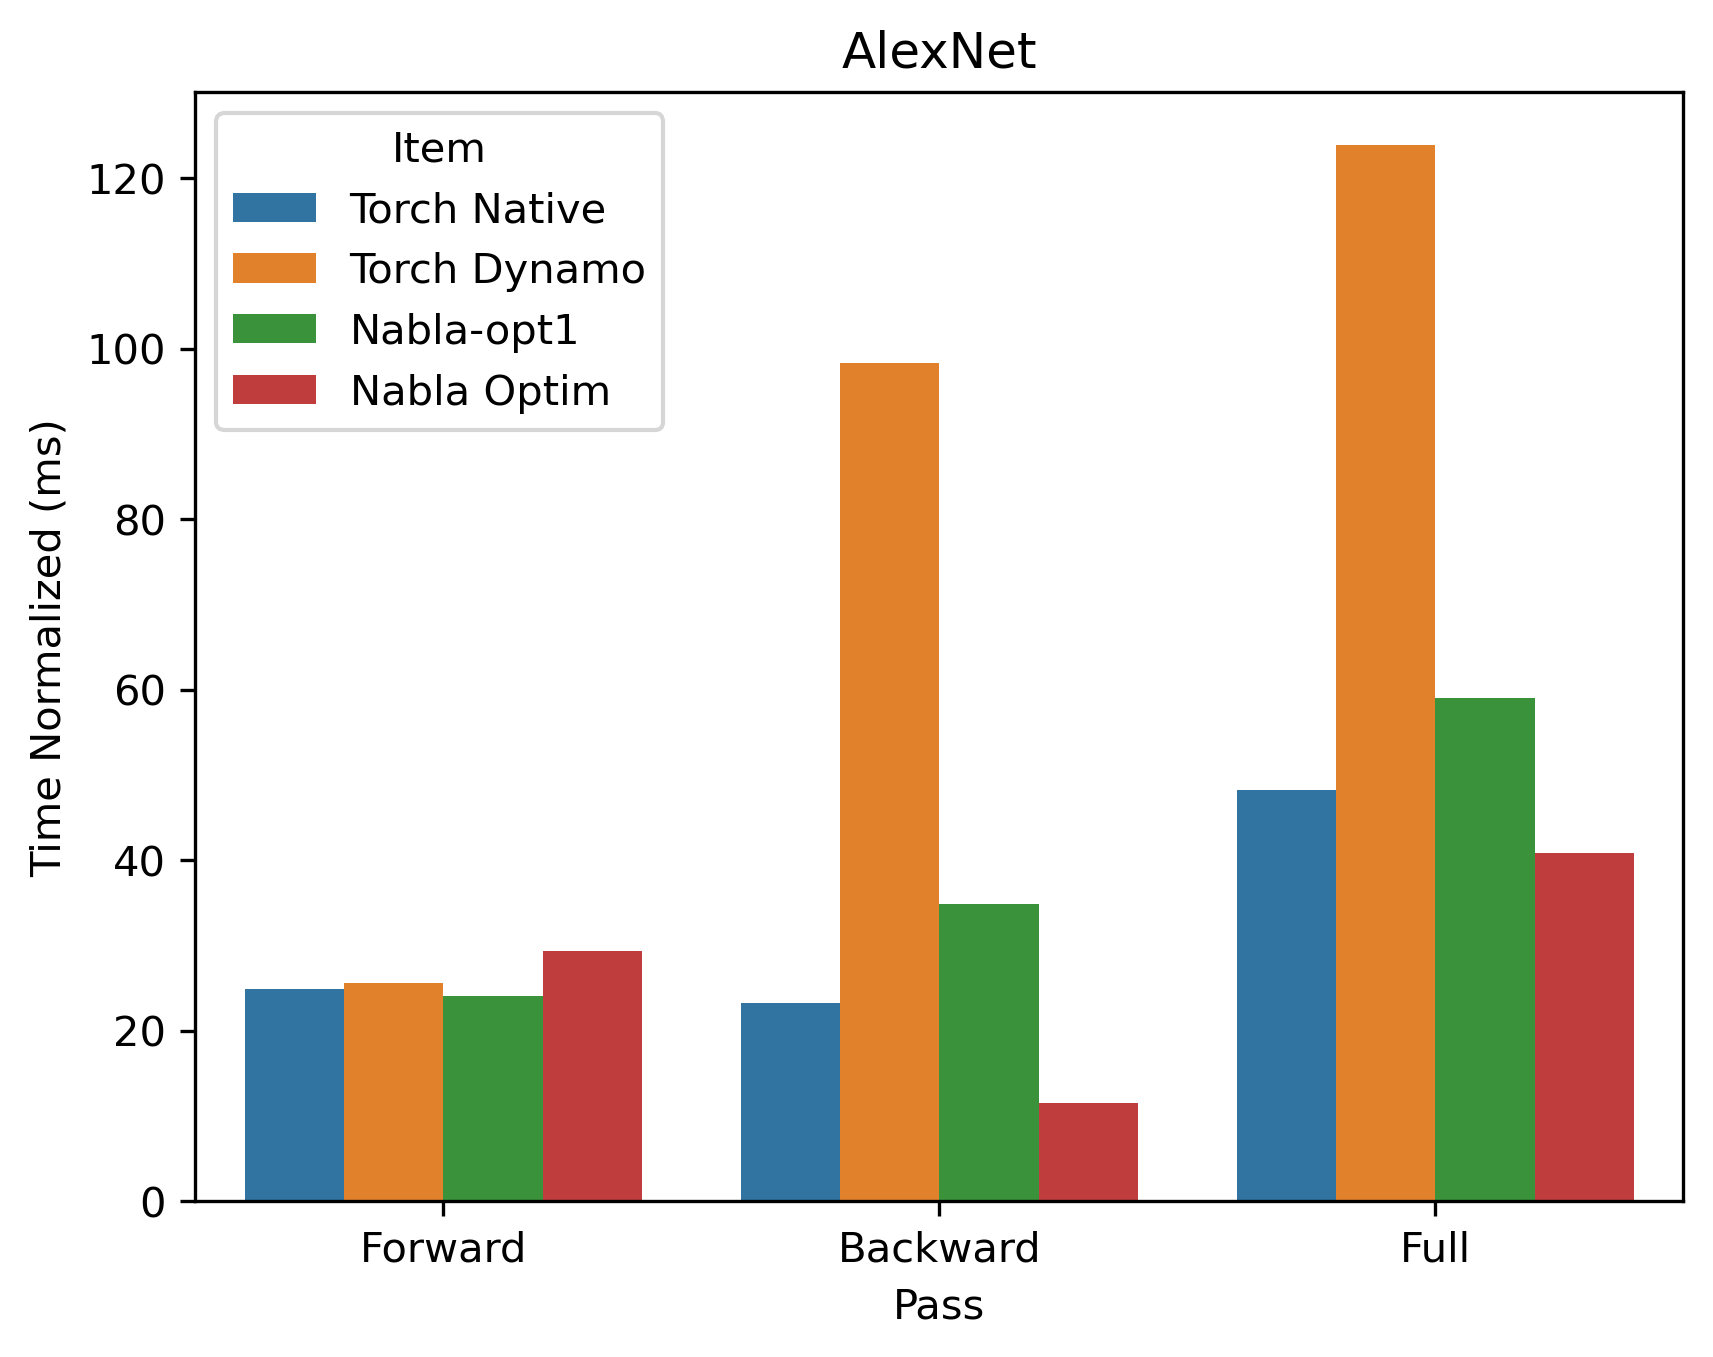

In [14]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [15]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,24.925389,Forward,Torch Native,1.024545
0,25.537172,Forward,Torch Dynamo,1.000000
0,24.118182,Forward,Nabla-opt1,1.058835
0,29.354545,Forward,Nabla Optim,0.869956


In [16]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,23.255015,Backward,Torch Native,4.228256
0,98.328161,Backward,Torch Dynamo,1.000000
0,34.855056,Backward,Nabla-opt1,2.821059
0,11.495529,Backward,Nabla Optim,8.553601


In [17]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,48.180404,Full,Torch Native,2.570865
0,123.865334,Full,Torch Dynamo,1.000000
0,58.973238,Full,Nabla-opt1,2.100365
0,40.850074,Full,Nabla Optim,3.032194


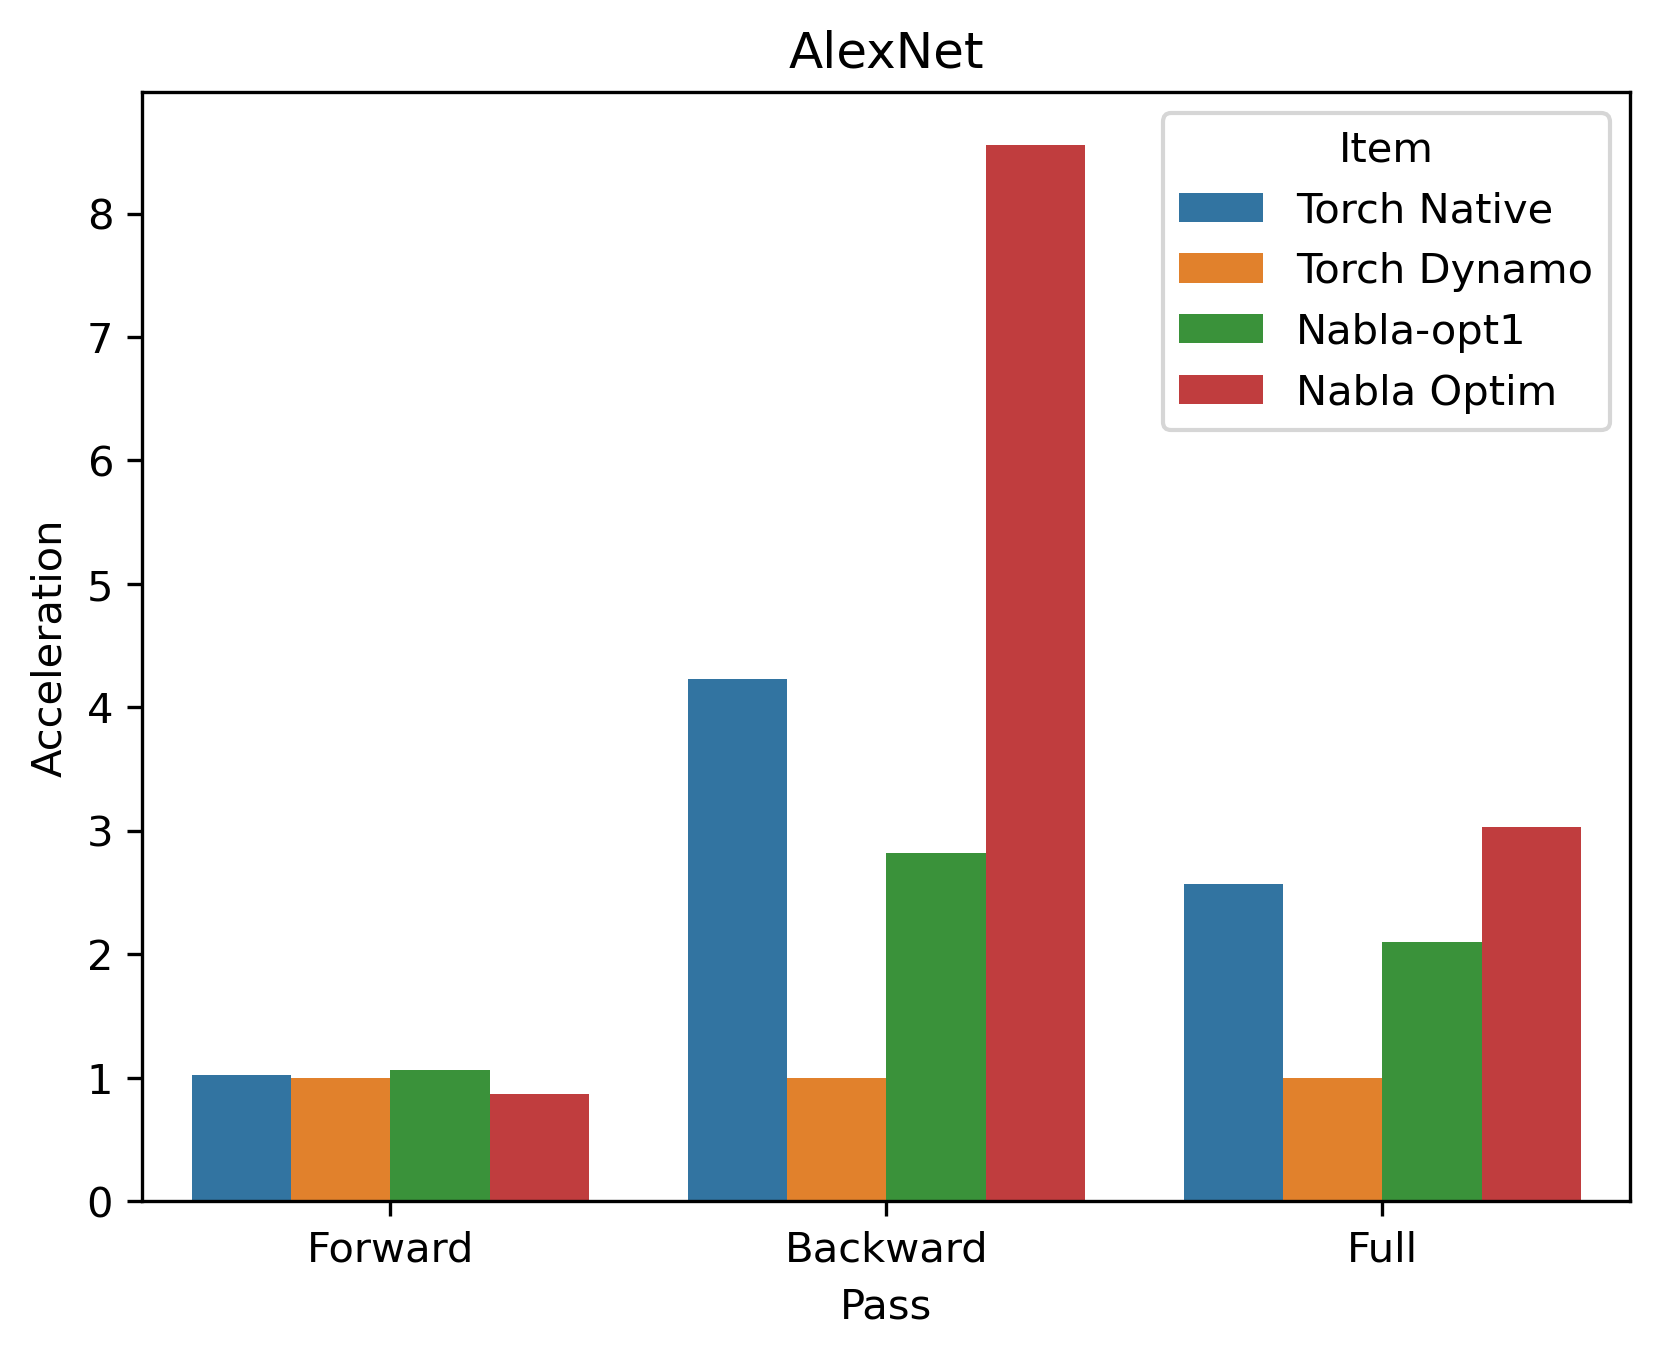

In [18]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")